# Autoencoder for Dimensionality Reduction

This notebook implements a fully connected autoencoder neural network for compressing high-dimensional spatiotemporal climate data into a lower-dimensional latent representation. The compressed features are subsequently used as input for the MLP prediction model.

## Architecture Overview

- **Input Layer**: 108-dimensional spatiotemporal features (2 time steps × 6 variables × 9 spatial points)
- **Encoder**: 108D → 128D → 32D latent space
- **Decoder**: 32D → 128D → 108D reconstructed output
- **Compression Ratio**: 3.4:1 reduction while preserving essential patterns

## Objectives

1. Learn compact representations of spatiotemporal patterns
2. Reduce computational complexity for downstream models
3. Extract meaningful features while minimizing reconstruction error

In [1]:
# Core libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Data processing
import xarray as xr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import os

# Visualization
import matplotlib.pyplot as plt

In [2]:
# Set random seeds for reproducibility
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {SEED} for reproducibility")

Random seed set to 42 for reproducibility


## 1. Data Loading and Preprocessing

### 1.1 Load Prepared Datasets

Load the preprocessed spatiotemporal datasets generated in the previous notebook. Each sample contains features from a 3×3 spatial grid over 2 time steps.

In [3]:
# Configuration
VARIABLES = ["u10", "v10", "mwp", "swh", "mwd_sin", "mwd_cos"]
N_TRAIN_SAMPLES = 10000
N_TEST_SAMPLES = 2000
NEIGH_LAT, NEIGH_LON = 1, 1  # 3×3 spatial grid
TIME_HORIZON = 2
DATA_FOLDER = 'dataset_final'

# Load training data
train_file = f"{DATA_FOLDER}/AE_train_data_{N_TRAIN_SAMPLES}_{VARIABLES}.npy"
train_data = np.load(train_file)
X_train = torch.tensor(train_data, dtype=torch.float32)

# Load testing data
test_file = f"{DATA_FOLDER}/AE_test_data_{N_TEST_SAMPLES}_{VARIABLES}.npy"
test_data = np.load(test_file)
X_test = torch.tensor(test_data, dtype=torch.float32)

# Display dataset information
print("Dataset Information")
print("=" * 60)
print(f"Variables: {VARIABLES}")
print(f"Spatial grid: {2*NEIGH_LAT+1}×{2*NEIGH_LON+1} = 9 points")
print(f"Temporal horizon: {TIME_HORIZON} time steps")
print(f"\nTraining samples: {X_train.shape[0]:,}")
print(f"Testing samples: {X_test.shape[0]:,}")
print(f"Features per sample: {X_train.shape[1]} ({TIME_HORIZON} × 9 × {len(VARIABLES)})")

# Calculate dataset statistics
print(f"\nData Statistics (Training):")
print(f"  Mean: {X_train.mean():.4f}")
print(f"  Std: {X_train.std():.4f}")
print(f"  Min: {X_train.min():.4f}")
print(f"  Max: {X_train.max():.4f}")

Dataset Information
Variables: ['u10', 'v10', 'mwp', 'swh', 'mwd_sin', 'mwd_cos']
Spatial grid: 3×3 = 9 points
Temporal horizon: 2 time steps

Training samples: 10,000
Testing samples: 2,000
Features per sample: 108 (2 × 9 × 6)

Data Statistics (Training):
  Mean: 2.0941
  Std: 4.5008
  Min: -20.7462
  Max: 23.1409


### 1.2 Data Normalization

Apply standardization (zero mean, unit variance) to improve training stability and convergence speed.

In [4]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

n_features = len(VARIABLES)

# (samples, time, point, feature)
X_train_all = X_train.reshape(X_train.shape[0], TIME_HORIZON, 9, n_features)
X_test_all  = X_test.reshape(X_test.shape[0],  TIME_HORIZON, 9, n_features)

# Flatten only time & space, keep features separate
X_train_feat = np.array(X_train_all).reshape(-1, n_features)
X_test_feat  = np.array(X_test_all).reshape(-1, n_features)

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_feat)
X_test_norm  = scaler.transform(X_test_feat)

X_train_norm_all = X_train_norm.reshape(X_train_all.shape)
X_test_norm_all  = X_test_norm.reshape(X_test_all.shape)

def feature_stats_table(X, feature_names):
    stats = {
        "mean": X.mean(axis=0),
        "std":  X.std(axis=0),
        "min":  X.min(axis=0),
        "max":  X.max(axis=0),
    }
    return pd.DataFrame(stats, index=feature_names)

print(X_train_feat.shape, X_train_norm.shape)

train_stats = feature_stats_table(X_train_norm, VARIABLES)
test_stats  = feature_stats_table(X_test_norm, VARIABLES)

print("\nTraining set normalization stats:")
print(train_stats.round(4))

print("\nTest set normalization stats:")
print(test_stats.round(4))


(180000, 6) (180000, 6)

Training set normalization stats:
         mean  std     min     max
u10      -0.0  1.0 -3.2740  3.8901
v10       0.0  1.0 -3.4555  4.0684
mwp      -0.0  1.0 -2.1775  4.1078
swh       0.0  1.0 -1.2706  5.6515
mwd_sin   0.0  1.0 -0.9572  2.5859
mwd_cos   0.0  1.0 -2.7480  1.0647

Test set normalization stats:
           mean     std     min     max
u10     -0.2390  1.0359 -2.8296  3.2296
v10     -0.2155  0.8689 -2.5184  2.7619
mwp      0.0032  0.9647 -1.9980  3.8567
swh     -0.1486  0.8605 -1.2473  4.5587
mwd_sin  0.2607  1.0639 -0.9572  2.5859
mwd_cos  0.2517  0.8794 -2.7480  1.0647


C:\Users\berna\AppData\Local\Temp\ipykernel_32912\2245218578.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_train_feat = np.array(X_train_all).reshape(-1, n_features)
C:\Users\berna\AppData\Local\Temp\ipykernel_32912\2245218578.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_test_feat  = np.array(X_test_all).reshape(-1, n_features)


In [5]:
X_train_sample = X_train_norm_all.reshape(X_train.shape[0], -1)
X_test_sample  = X_test_norm_all.reshape(X_test.shape[0], -1)

print(X_train_sample.shape, X_test_sample.shape)

(10000, 108) (2000, 108)


## 2. Autoencoder Architecture

### 2.1 Model Definition

Define a symmetric autoencoder with:
- **Encoder**: Progressively compresses input to latent representation
- **Decoder**: Reconstructs original dimensions from latent space
- **Activation**: ReLU for non-linear transformations

In [6]:
class Autoencoder(nn.Module):
    """
    Fully connected autoencoder for dimensionality reduction.
    
    Args:
        input_dim (int): Input feature dimension
        latent_dim (int): Compressed latent space dimension
        hidden_dim (int): Hidden layer dimension
    """
    def __init__(self, input_dim, latent_dim, hidden_dim):
        super(Autoencoder, self).__init__()
        
        # Encoder: compress to latent space
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, latent_dim),
            nn.ReLU()
        )
        
        # Decoder: reconstruct from latent space
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        """Full autoencoder pass: encode then decode"""
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed
    
    def encode(self, x):
        """Extract latent representation"""
        return self.encoder(x)

# Architecture parameters
INPUT_DIM = X_train.shape[1]
LATENT_DIM = 32
HIDDEN_DIM = 128

print("Autoencoder Architecture")
print("=" * 60)
print(f"Input dimension:     {INPUT_DIM}")
print(f"Hidden dimension:    {HIDDEN_DIM}")
print(f"Latent dimension:    {LATENT_DIM}")
print(f"Compression ratio:   {INPUT_DIM/LATENT_DIM:.1f}:1")
print(f"\nEncoder pathway:     {INPUT_DIM} → {HIDDEN_DIM} → {HIDDEN_DIM//2} → {LATENT_DIM}")
print(f"Decoder pathway:     {LATENT_DIM} → {HIDDEN_DIM//2} → {HIDDEN_DIM} → {INPUT_DIM}")

Autoencoder Architecture
Input dimension:     108
Hidden dimension:    128
Latent dimension:    32
Compression ratio:   3.4:1

Encoder pathway:     108 → 128 → 64 → 32
Decoder pathway:     32 → 64 → 128 → 108


## 3. Model Training

### 3.1 Data Splitting

Split training data into training (80%) and validation (20%) subsets for monitoring overfitting.

In [7]:
# Split normalized data
X_train_split, X_val_split = train_test_split(
    X_train_sample, test_size=0.2, random_state=42
)

print("Data Split")
print("=" * 60)
print(f"Training samples:   {len(X_train_split):,} (80%)")
print(f"Validation samples: {len(X_val_split):,} (20%)")

Data Split
Training samples:   8,000 (80%)
Validation samples: 2,000 (20%)


In [8]:
### 3.2 Training Configuration and Execution

# Training hyperparameters
EPOCHS = 500
LEARNING_RATE = 0.0005
BATCH_SIZE = 64
PATIENCE = 10  # Early stopping patience

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training Configuration")
print("=" * 60)
print(f"Device: {device}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Early stopping patience: {PATIENCE}")

# Initialize model
model = Autoencoder(INPUT_DIM, LATENT_DIM, HIDDEN_DIM).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Create data loaders
train_tensor = torch.tensor(X_train_split, dtype=torch.float32)
val_tensor = torch.tensor(X_val_split, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(train_tensor), 
    batch_size=BATCH_SIZE, 
    shuffle=True
)
val_loader = DataLoader(
    TensorDataset(val_tensor), 
    batch_size=BATCH_SIZE, 
    shuffle=False
)

# Training tracking
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"\nStarting training...\n")

# Training loop
for epoch in range(EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0
    
    for batch in train_loader:
        data = batch[0].to(device)
        
        optimizer.zero_grad()
        reconstructed = model(data)
        loss = criterion(reconstructed, data)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for batch in val_loader:
            data = batch[0].to(device)
            reconstructed = model(data)
            loss = criterion(reconstructed, data)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f} ✓")
    else:
        patience_counter += 1
        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f} ({patience_counter}/{PATIENCE})")
        
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            print(f"Best validation loss: {best_val_loss:.6f}")
            break

    

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nRestored best model (Val Loss: {best_val_loss:.6f})")


Training Configuration
Device: cuda
Epochs: 500
Learning rate: 0.0005
Batch size: 64
Early stopping patience: 10

Starting training...

Epoch   1/500 | Train: 0.498687 | Val: 0.135808 ✓
Epoch  50/500 | Train: 0.004710 | Val: 0.004802 ✓
Epoch 100/500 | Train: 0.002759 | Val: 0.002988 (1/10)
Epoch 150/500 | Train: 0.001977 | Val: 0.002093 ✓
Epoch 200/500 | Train: 0.001607 | Val: 0.001857 (4/10)

Early stopping at epoch 213
Best validation loss: 0.001631

Restored best model (Val Loss: 0.001631)


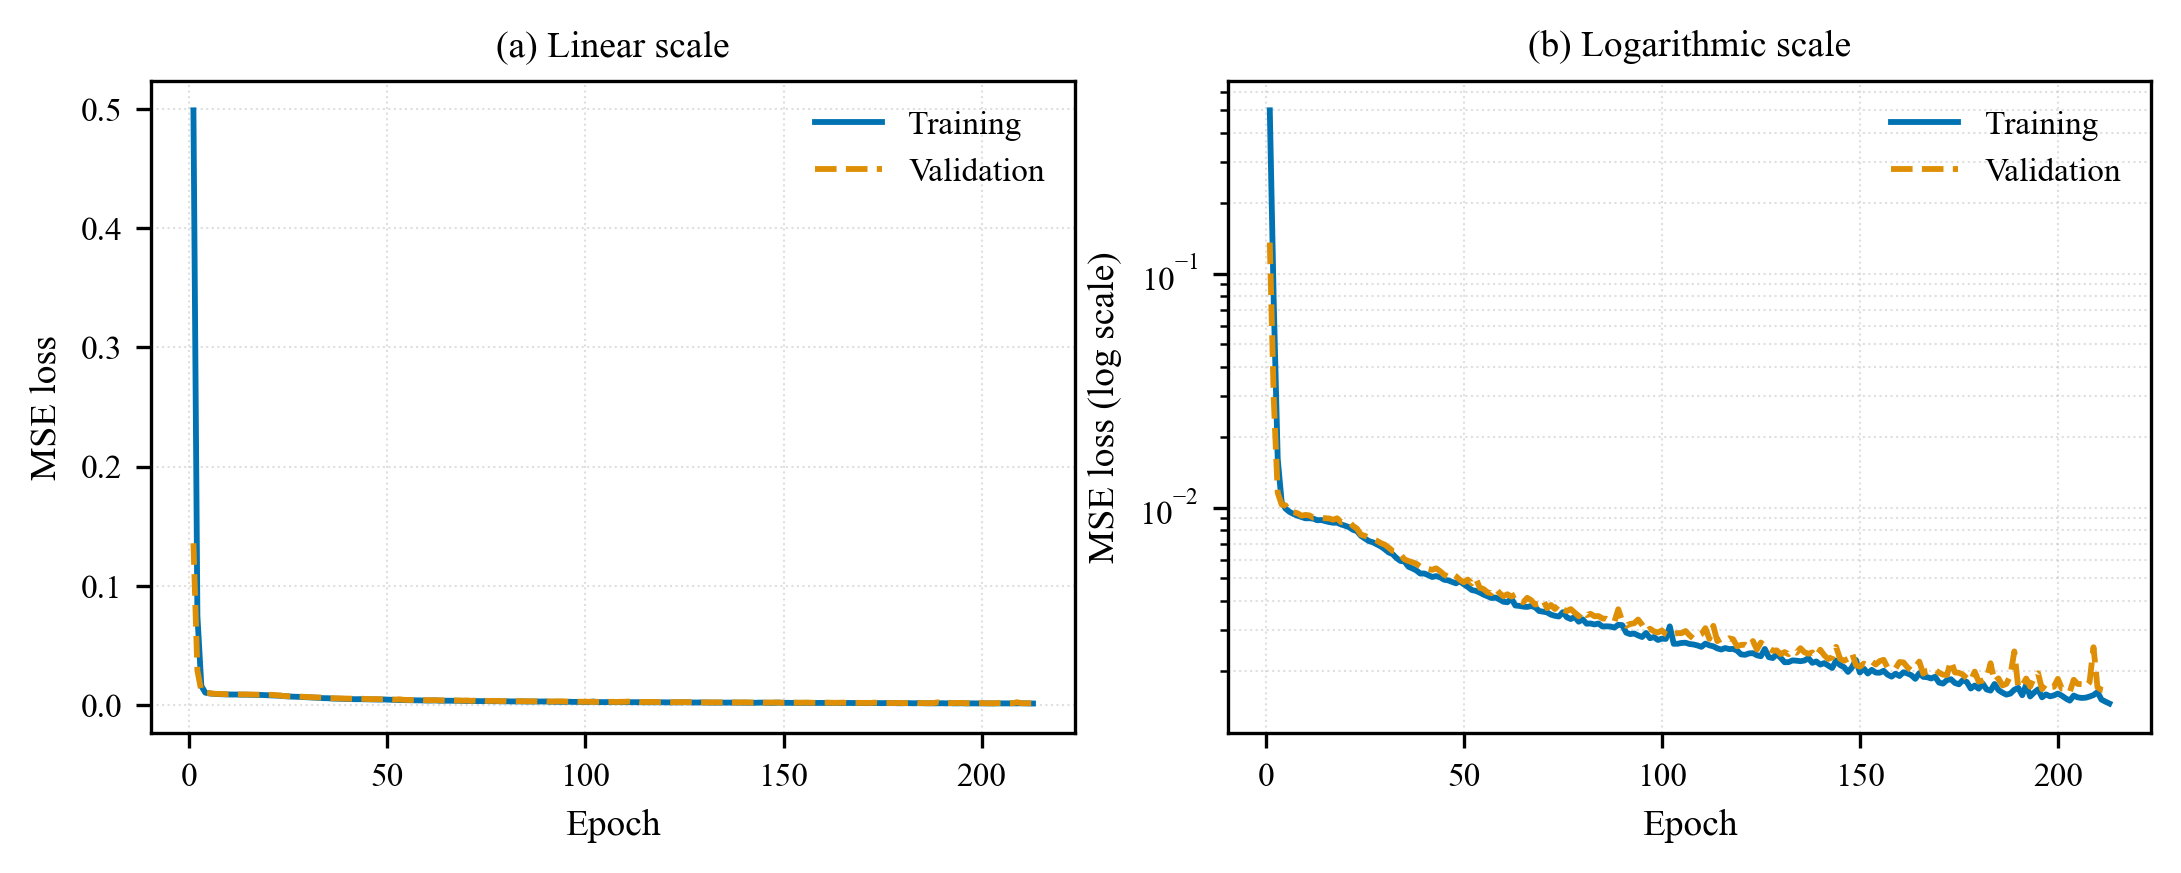


Training summary:
  Total epochs      : 213
  Final train loss  : 0.001457
  Best val loss     : 0.001631
  Figure saved      : AE_training_history.png


In [9]:
### 5.3 Training History Visualization (IEEE)

import matplotlib.pyplot as plt

# -------------------------------
# IEEE publication settings
# -------------------------------
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "mathtext.fontset": "stix",
})

epochs = range(1, len(train_losses) + 1)

# IEEE double-column width (7.16 in)
fig, axes = plt.subplots(1, 2, figsize=(7.16, 2.8), dpi=300)

# IEEE colorblind-safe colors
color_train = "#0173B2"  # Blue
color_val   = "#DE8F05"  # Orange

# ===============================
# (a) Linear scale
# ===============================
axes[0].plot(
    epochs, train_losses,
    label="Training",
    linewidth=1.4,
    color=color_train
)
axes[0].plot(
    epochs, val_losses,
    label="Validation",
    linewidth=1.4,
    linestyle="--",
    color=color_val
)

axes[0].set_title("(a) Linear scale", pad=6)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss")
axes[0].grid(True, linestyle=":", linewidth=0.5, alpha=0.4)
axes[0].legend(frameon=False, loc="best")

# ===============================
# (b) Logarithmic scale
# ===============================
axes[1].plot(
    epochs, train_losses,
    label="Training",
    linewidth=1.4,
    color=color_train
)
axes[1].plot(
    epochs, val_losses,
    label="Validation",
    linewidth=1.4,
    linestyle="--",
    color=color_val
)

axes[1].set_yscale("log")
axes[1].set_title("(b) Logarithmic scale", pad=6)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE loss (log scale)")
axes[1].grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.4)
axes[1].legend(frameon=False, loc="best")

# -------------------------------
# Layout and export
# -------------------------------
plt.tight_layout(pad=0.4)
plt.savefig(
    "images, figures and videos2/AE_training_history.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# -------------------------------
# Console summary (optional)
# -------------------------------
print("\nTraining summary:")
print(f"  Total epochs      : {len(train_losses)}")
print(f"  Final train loss  : {train_losses[-1]:.6f}")
print(f"  Best val loss     : {min(val_losses):.6f}")
print("  Figure saved      : AE_training_history.png")


## 4. Model Evaluation

### 4.1 Generate Reconstructions

Evaluate reconstruction quality on the test set by comparing original inputs with autoencoder outputs.

In [10]:
# Generate predictions on test set
model.eval()
X_test_tensor = torch.tensor(X_test_sample, dtype=torch.float32).to(device)

with torch.no_grad():
    reconstructed = model(X_test_tensor).cpu().numpy()
    latent_representations = model.encode(X_test_tensor).cpu().numpy()

print("Reconstruction Results")
print("=" * 60)
print(f"Original data shape:   {X_test_sample.shape}")
print(f"Latent shape:          {latent_representations.shape}")
print(f"Reconstructed shape:   {reconstructed.shape}")
print(f"Compression achieved:  {X_test_sample.shape[1]} → {latent_representations.shape[1]} features")

Reconstruction Results
Original data shape:   (2000, 108)
Latent shape:          (2000, 32)
Reconstructed shape:   (2000, 108)
Compression achieved:  108 → 32 features


### 4.2 Reconstruction Error Analysis (Original Scale)

Calculate reconstruction errors in the original data scale for interpretability.

In [11]:
# Transform back to original scale
reconstructed_feat = reconstructed.reshape(-1, n_features)
reconstructed_original_feat = scaler.inverse_transform(reconstructed_feat)
reconstructed_original_sample = reconstructed_original_feat.reshape(X_test_sample.shape)
X_test_original = X_test.cpu().numpy()

# Calculate error metrics
mae = np.mean(np.abs(reconstructed_original_sample - X_test_original), axis=0)
mse = np.mean((reconstructed_original_sample - X_test_original) ** 2, axis=0)
rmse = np.sqrt(mse)

print("Reconstruction Errors (Original Scale)")
print("=" * 60)
print(f"{'Feature':>10} {'MAE':>15} {'RMSE':>15}")
print("-" * 60)
for i in range(len(mae)):
    print(f"{i+1:>10} {mae[i]:>15.4f} {rmse[i]:>15.4f}")

print("\nSummary Statistics:")
print(f"  Mean RMSE: {np.mean(rmse):.4f}")
print(f"  Max RMSE:  {np.max(rmse):.4f}")
print(f"  Mean MAE:   {np.mean(mae):.4f}")

Reconstruction Errors (Original Scale)
   Feature             MAE            RMSE
------------------------------------------------------------
         1          0.2668          0.3986
         2          0.3145          0.5073
         3          0.0846          0.1238
         4          0.0580          0.0882
         5          0.0240          0.0461
         6          0.0240          0.0635
         7          0.1741          0.2847
         8          0.2565          0.4456
         9          0.0638          0.0900
        10          0.0458          0.0680
        11          0.0162          0.0290
        12          0.0160          0.0341
        13          0.2223          0.3218
        14          0.3540          0.5962
        15          0.0703          0.1002
        16          0.0466          0.0663
        17          0.0227          0.0417
        18          0.0239          0.0528
        19          0.1820          0.2893
        20          0.2309          0.39

In [12]:
### 4.3 Reconstruction Error Analysis (Normalized Scale)

# Calculate errors in normalized space
mae_norm = np.mean(np.abs(reconstructed - X_test_sample), axis=0)
mse_norm = np.mean((reconstructed - X_test_sample) ** 2, axis=0)
rmse_norm = np.sqrt(mse_norm)

print("Reconstruction Errors (Normalized Scale)")
print("=" * 60)
print(f"{'Feature':>10} {'MAE':>15} {'RMSE':>15}")
print("-" * 60)
for i in range(len(mse_norm)):
    print(f"{i+1:>10} {mae_norm[i]:>15.4f} {rmse_norm[i]:>15.4f}")

print("\nSummary Statistics:")
print(f"  Mean RMSE: {np.mean(rmse_norm):.4f}")
print(f"  Max RMSE:  {np.max(rmse_norm):.4f}")
print(f"  Mean MAE:   {np.mean(mae_norm):.4f}")

Reconstruction Errors (Normalized Scale)
   Feature             MAE            RMSE
------------------------------------------------------------
         1          0.0532          0.0795
         2          0.0539          0.0870
         3          0.0543          0.0795
         4          0.0433          0.0657
         5          0.0426          0.0816
         6          0.0457          0.1210
         7          0.0347          0.0568
         8          0.0440          0.0764
         9          0.0410          0.0578
        10          0.0341          0.0507
        11          0.0286          0.0514
        12          0.0304          0.0650
        13          0.0443          0.0641
        14          0.0607          0.1022
        15          0.0451          0.0644
        16          0.0347          0.0494
        17          0.0401          0.0738
        18          0.0455          0.1006
        19          0.0363          0.0577
        20          0.0396          0.

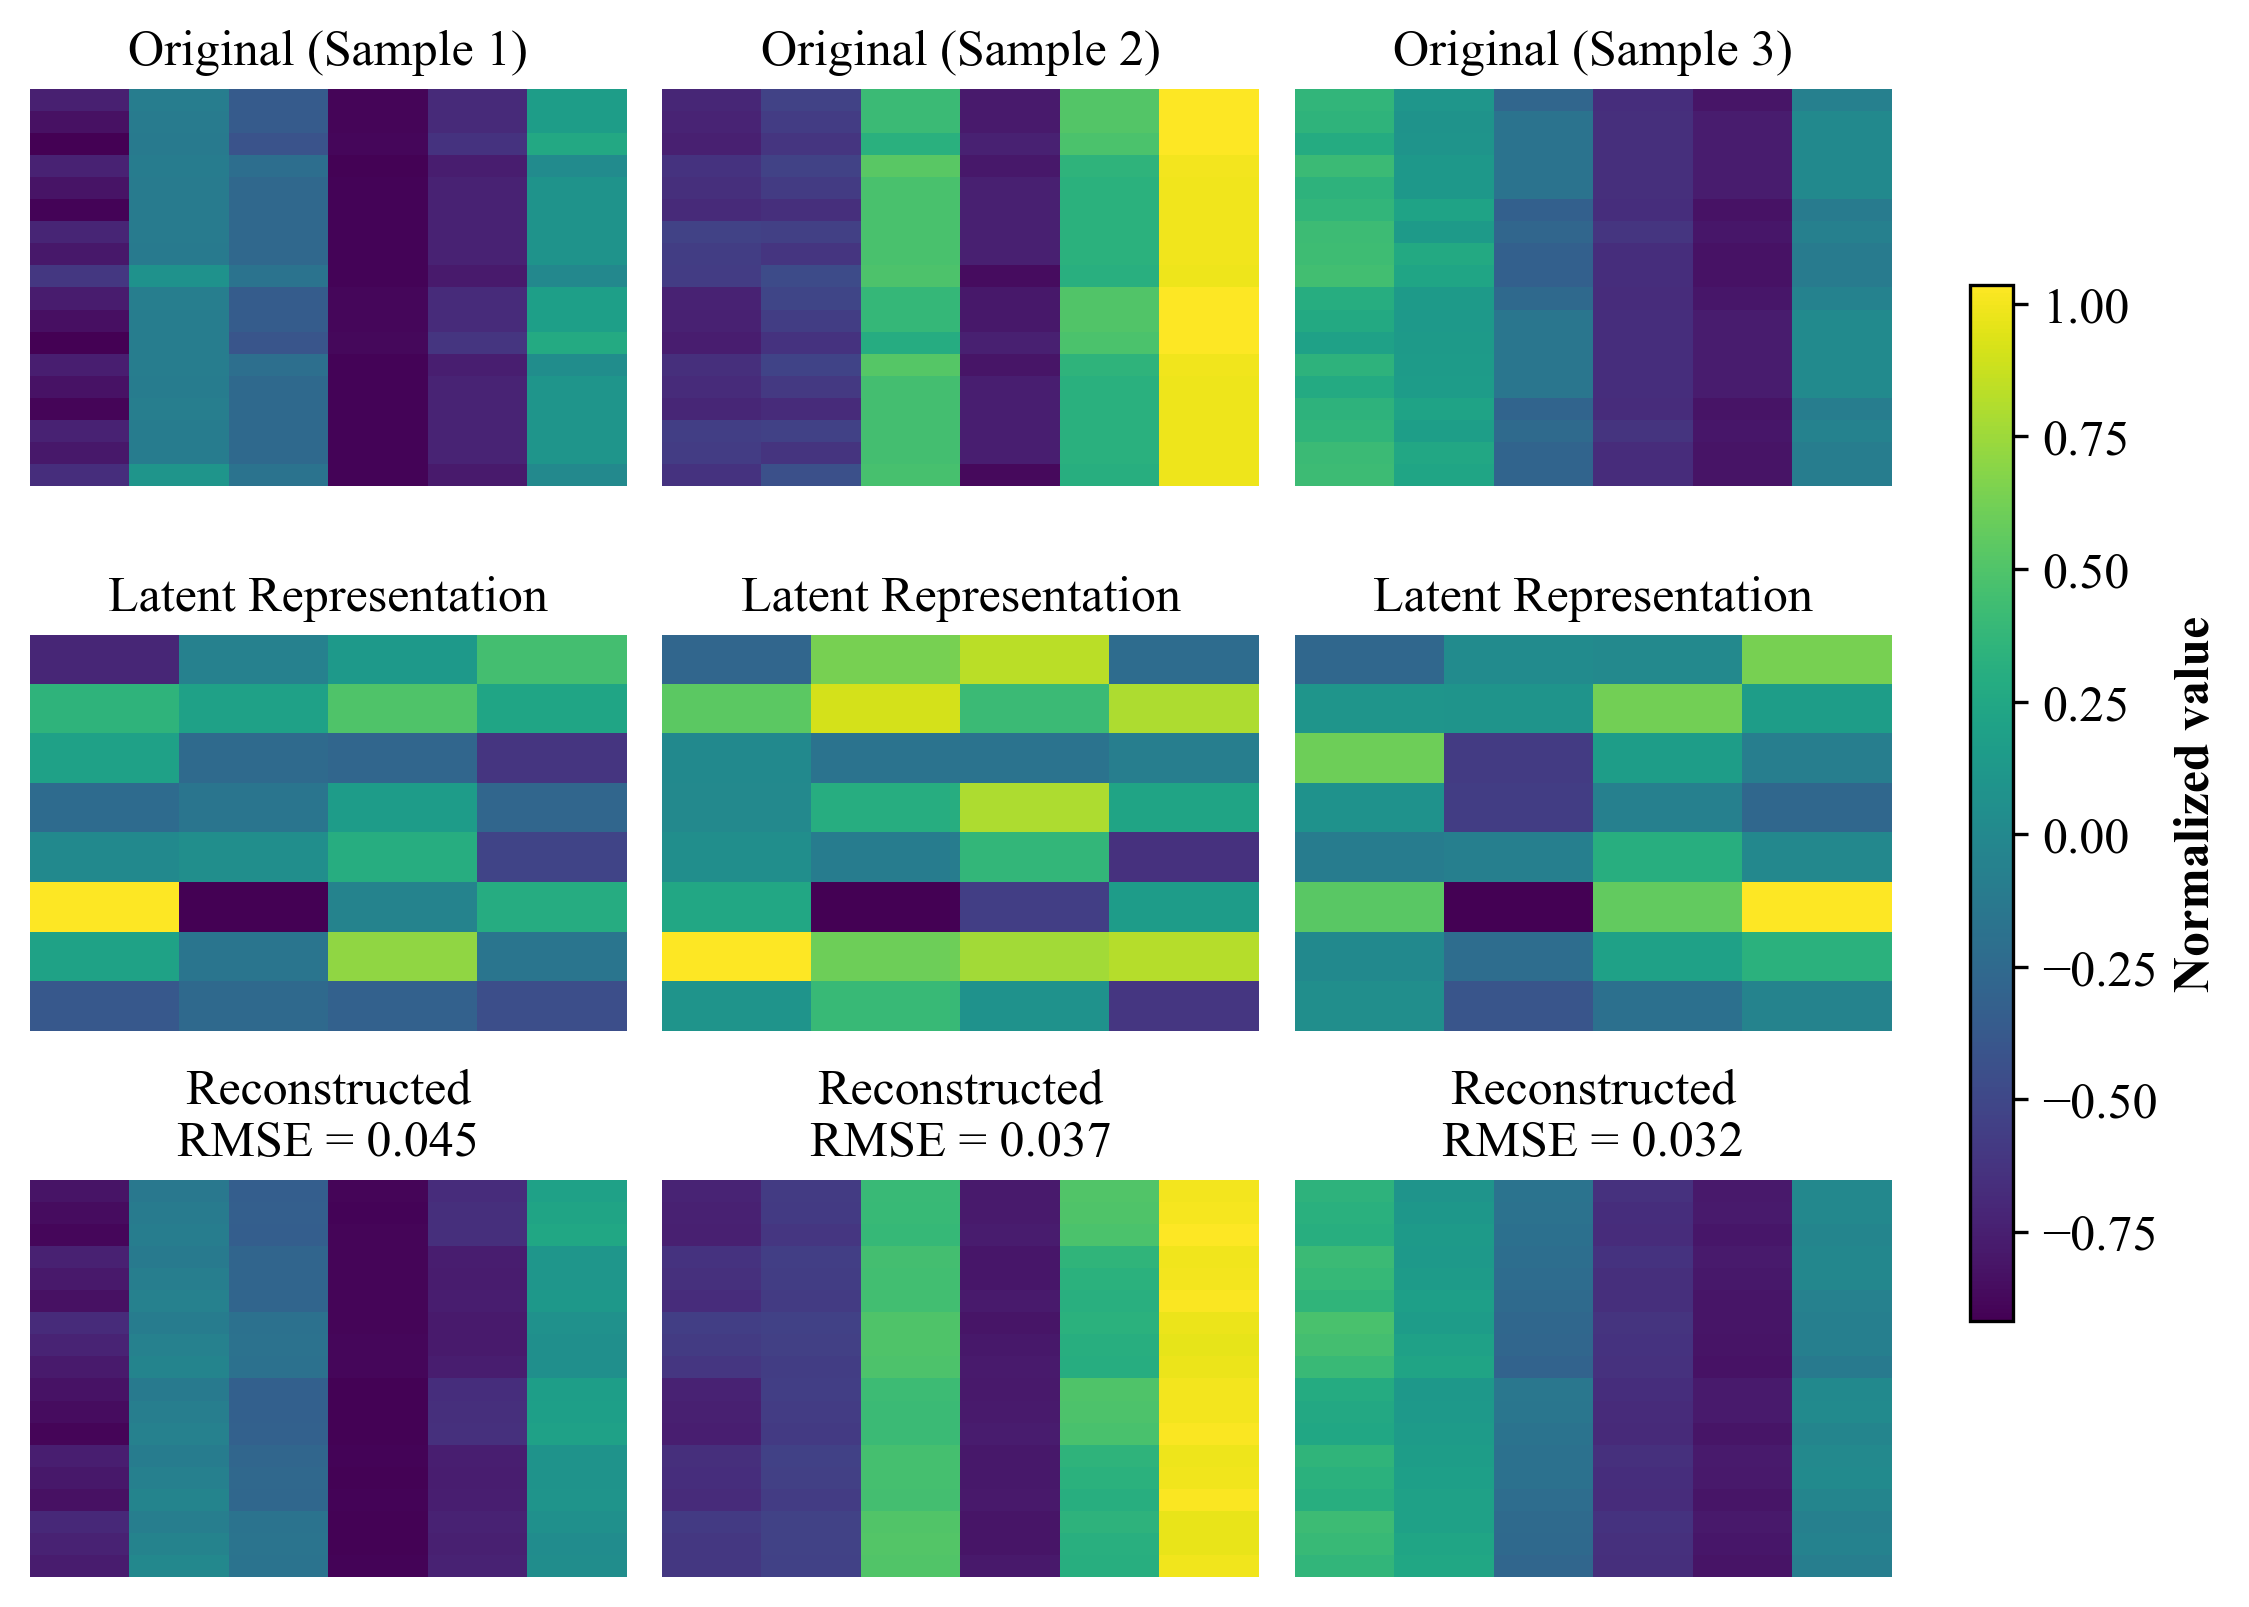

In [13]:
# ===============================
# IEEE-compliant autoencoder visualization with larger text
# ===============================

import matplotlib.pyplot as plt
import numpy as np

n_samples = 3

# Figure size for double-column
fig, axes = plt.subplots(
    3, n_samples,
    figsize=(7.16, 5.4),  # double-column width
    dpi=300
)

# Global color scale for Original and Reconstructed
vmin = np.min(X_test_sample[:n_samples])
vmax = np.max(X_test_sample[:n_samples])

# -------------------------------
# Plot samples
# -------------------------------
for i in range(n_samples):
    sample_mse = np.mean((reconstructed[i] - X_test_sample[i]) ** 2)
    sample_rmse = np.sqrt(sample_mse)

    # Original
    axes[0, i].imshow(
        X_test_sample[i].reshape(18, 6),
        cmap="viridis",
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )
    axes[0, i].set_title(f"Original (Sample {i+1})", fontsize=12)
    axes[0, i].axis("off")

    # Latent
    axes[1, i].imshow(
        latent_representations[i].reshape(8, 4),
        cmap="viridis",
        aspect="auto"
    )
    axes[1, i].set_title("Latent Representation", fontsize=12)
    axes[1, i].axis("off")

    # Reconstructed
    axes[2, i].imshow(
        reconstructed[i].reshape(18, 6),
        cmap="viridis",
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )
    axes[2, i].set_title(f"Reconstructed\nRMSE = {sample_rmse:.3f}", fontsize=12)
    axes[2, i].axis("off")

# -------------------------------
# Row labels
# -------------------------------
axes[0, 0].set_ylabel("Input", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Latent", fontsize=12, fontweight='bold')
axes[2, 0].set_ylabel("Output", fontsize=12, fontweight='bold')

# -------------------------------
# Layout + colorbar
# -------------------------------
plt.tight_layout(rect=[0.0, 0.0, 0.90, 1.0])

cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.64])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Normalized value", fontsize=12, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# -------------------------------
# Save figure
# -------------------------------
plt.savefig(
    "images, figures and videos2/autoencoder_samples.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 5. Model Persistence

### 5.1 Save Trained Components

Save the trained autoencoder model and data scaler for use in subsequent notebooks.

In [14]:
# Configuration
SAVE_MODEL = True
MODEL_DIR = 'model'

if SAVE_MODEL:
    # Create directory
    os.makedirs(MODEL_DIR, exist_ok=True)
    
    # Save scaler
    scaler_path = f'{MODEL_DIR}/scaler2.save'
    joblib.dump(scaler, scaler_path)
    
    # Save model state dictionary
    model_path = f'{MODEL_DIR}/autoencoder_model2.pth'
    torch.save(model.state_dict(), model_path)
    
    print("Model Components Saved")
    print("=" * 60)
    print(f"✓ Scaler saved to: {scaler_path}")
    print(f"✓ Model saved to: {model_path}")
    print(f"\nModel can be loaded using:")
    print(f"  scaler = joblib.load('{scaler_path}')")
    print(f"  model.load_state_dict(torch.load('{model_path}'))")
else:
    print("Model saving skipped (SAVE_MODEL=False)")

Model Components Saved
✓ Scaler saved to: model/scaler2.save
✓ Model saved to: model/autoencoder_model2.pth

Model can be loaded using:
  scaler = joblib.load('model/scaler2.save')
  model.load_state_dict(torch.load('model/autoencoder_model2.pth'))
